In [ ]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.tree import export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
# fetching data to make dataframe
df = pd.read_csv("bank-full.csv", sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


In [ ]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# checking statistics of the data
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


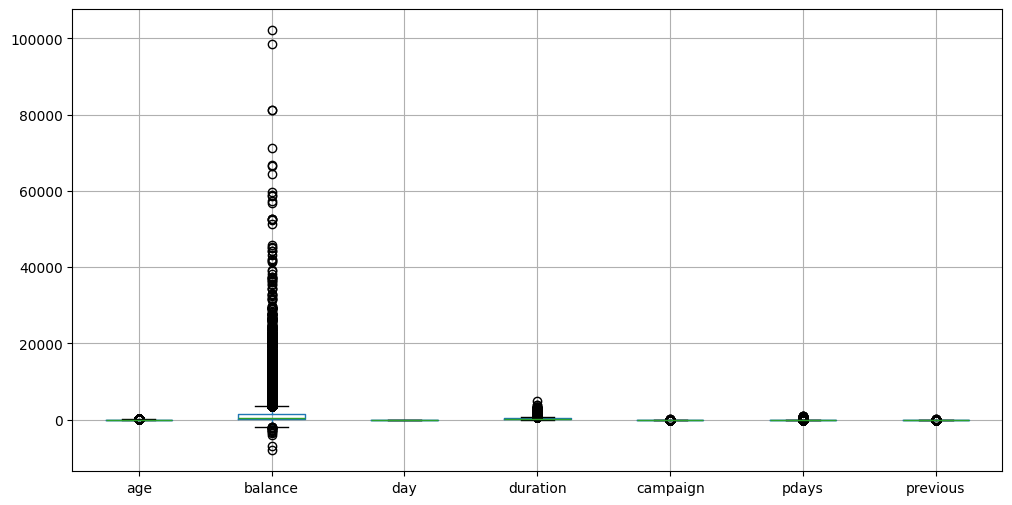

In [ ]:
# checking outliers in numerical features
plt.figure(figsize = (12, 6))
df[num_features].boxplot()
plt
plt.show()

In [ ]:
# splitting data into train and test sets
x_train, x_test, y_train, y_test = train_test_split(df.drop("y", axis = 1), df['y'], test_size = 0.2, random_state = 42)

In [ ]:
# identifying numerical and categorical features
num_cols = x_train.select_dtypes(include = 'Int64').columns
cat_cols = x_train.select_dtypes(include = 'str').columns

print("Numerical features:", num_cols)
print("Categorical features:", cat_cols)

Numerical features: Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='str')
Categorical features: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='str')


In [ ]:
# encoding categorical features and scaling numerical features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ('num', StandardScaler(), num_cols)
    ]
)

x_train_encoded = preprocessor.fit_transform(x_train)
x_test_encoded = preprocessor.transform(x_test)

In [ ]:
# encoding target variable
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

# Logistic Regression

In [ ]:
# training and evaluating Logistic Regression model
model = LogisticRegression()
model.fit(x_train_encoded, y_train_encoded)

y_pred_lr = model.predict(x_test_encoded)

print(classification_report(y_test_encoded, y_pred_lr))


              precision    recall  f1-score   support

           0       0.92      0.98      0.94      7952
           1       0.65      0.34      0.45      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.66      0.70      9043
weighted avg       0.88      0.90      0.88      9043



In [76]:
confusion_matrix(y_test_encoded, y_pred_lr)

array([[7754,  198],
       [ 718,  373]])

# Training decision tree model

In [ ]:
# training and evaluating Decision Tree model
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train_encoded, y_train_encoded)

y_pred_dt = dt.predict(x_test_encoded)

print(classification_report(y_test_encoded, y_pred_dt))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7952
           1       0.48      0.49      0.48      1091

    accuracy                           0.87      9043
   macro avg       0.70      0.71      0.71      9043
weighted avg       0.88      0.87      0.87      9043



In [74]:
# tuned decision tree
dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt.fit(x_train_encoded, y_train_encoded)

y_pred_dt1 = dt.predict(x_test_encoded)
print(classification_report(y_test_encoded, y_pred_dt1))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7952
           1       0.65      0.33      0.44      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.65      0.69      9043
weighted avg       0.88      0.90      0.88      9043



In [ ]:
# extracting feature importance from the decision tree model
feature_names = preprocessor.get_feature_names_out()

importance = dt.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values(by='importance', ascending=False)

print(feat_imp.head(10))

                  feature  importance
47          num__duration    0.569681
42  cat__poutcome_success    0.299584
44               num__age    0.049397
35         cat__month_mar    0.039760
27   cat__contact_unknown    0.017580
36         cat__month_may    0.006090
21        cat__housing_no    0.004612
45           num__balance    0.002265
46               num__day    0.002221
13   cat__marital_married    0.001792


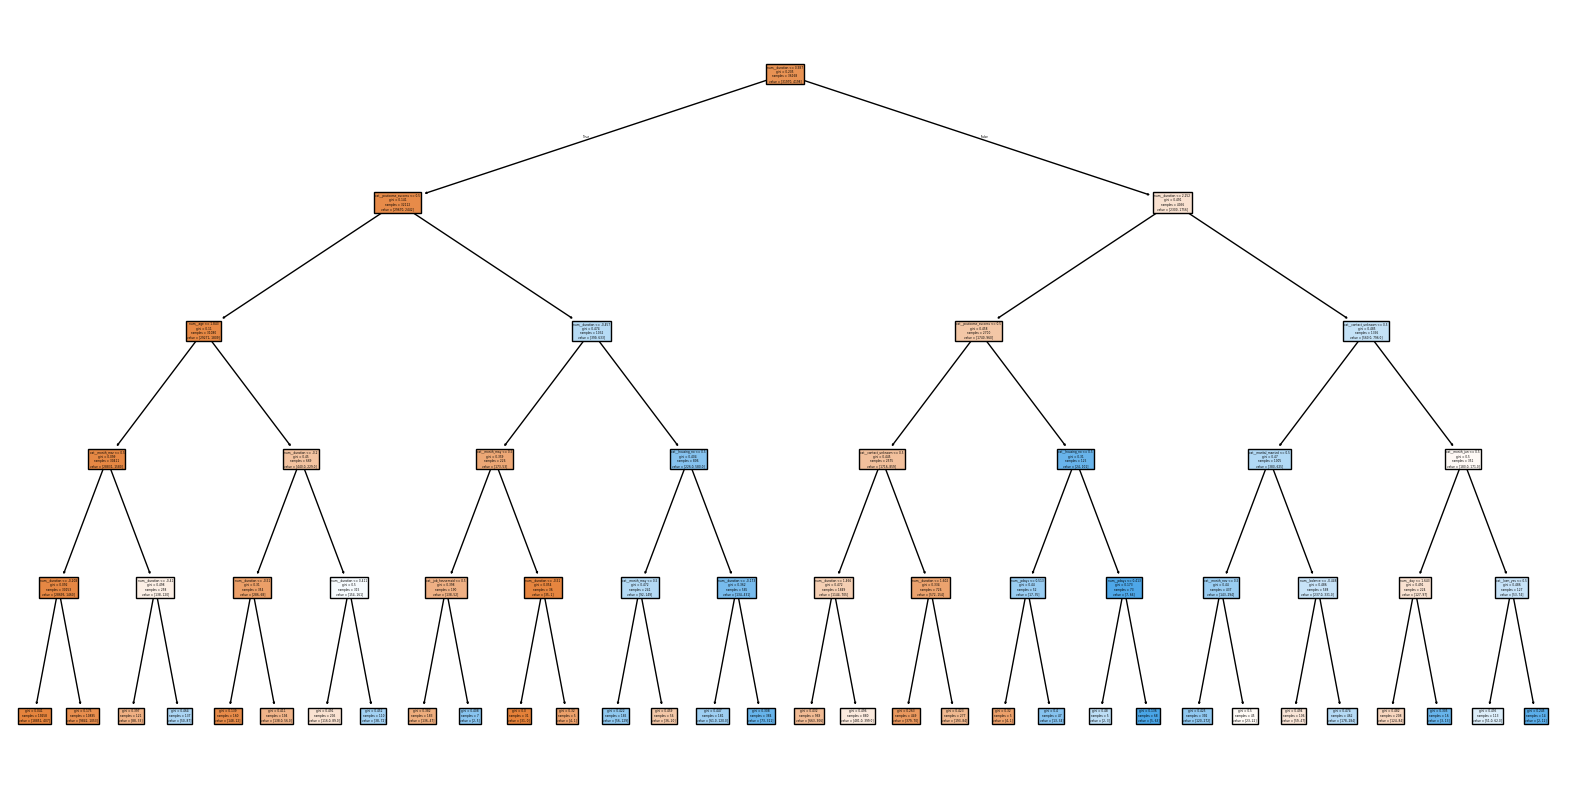

In [ ]:
# plotting the decision tree
plt.figure(figsize=(20,10))
plot_tree(dt, feature_names=feature_names, filled=True)
plt.show()

# Task D -Rule-Based Classification

In [ ]:
# printing the decision tree rules
tree_rules = export_text(dt, feature_names=list(feature_names))
print(tree_rules)

|--- num__duration <= 0.99
|   |--- cat__poutcome_success <= 0.50
|   |   |--- num__age <= 1.84
|   |   |   |--- cat__month_mar <= 0.50
|   |   |   |   |--- num__duration <= -0.21
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__duration >  -0.21
|   |   |   |   |   |--- class: 0
|   |   |   |--- cat__month_mar >  0.50
|   |   |   |   |--- num__duration <= -0.41
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__duration >  -0.41
|   |   |   |   |   |--- class: 1
|   |   |--- num__age >  1.84
|   |   |   |--- num__duration <= -0.20
|   |   |   |   |--- num__duration <= -0.51
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__duration >  -0.51
|   |   |   |   |   |--- class: 0
|   |   |   |--- num__duration >  -0.20
|   |   |   |   |--- num__duration <= 0.41
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- num__duration >  0.41
|   |   |   |   |   |--- class: 1
|   |--- cat__poutcome_success >  0.50
|   |   |--- num__duration <= -0.46
|   |   |   |--- 

1) Rule1:
if duration <= 0.99 and poutcome_success <= 0.50 and age <= 1.84 then customer will not subscribe term deposit
2) Rule2:
if duration <= 0.99 and poutcome_success <= 0.50 and age <= 1.84 and month = march and duraion > -0.40 then customer will subscribe the term deposit
3) Rule3:
if duration <= 0.99 and poutcome_success >  0.50 and age > 1.84 and duration <= -0.46 and month = may then customer will not subscribe
4) Rule4:
duration >  0.99 and duration <= 2.25 and poutcome_success <= 0.50 then customer will not subscribe
5) Rule5:
duration >  0.99 and duration >  2.25 and contact_unknown <= 0.50 and marital_status = unmarried and month_nov <= 0.50 then customer will subscribe the term deposit


1) Interpretability:
(a) Rules are easy to interpret
(b) They can be used by businesses easily without the help of experts

2) Performance:
(a) Rules are generally used for simplification and are less capable to learn complex patterns


# Task E -kNN (Lazy Learning) 

In [ ]:
# training and evaluating K-Nearest Neighbors model with different values of k
k_value = [1,3,5,7,9]
for k in k_value:
    
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train_encoded, y_train_encoded)
    y_pred_knn = knn.predict(x_test_encoded)

    print(50*("="))
    print("value of k=", k)
    print("accuracy score:", accuracy_score(y_test_encoded, y_pred_knn))
    print(50*("="))
    print(classification_report(y_test_encoded, y_pred_knn))

value of k= 1
accuracy score: 0.8814552692690479
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      7952
           1       0.51      0.45      0.48      1091

    accuracy                           0.88      9043
   macro avg       0.72      0.70      0.71      9043
weighted avg       0.88      0.88      0.88      9043

value of k= 3
accuracy score: 0.8925135463894726
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      7952
           1       0.58      0.40      0.47      1091

    accuracy                           0.89      9043
   macro avg       0.75      0.68      0.71      9043
weighted avg       0.88      0.89      0.88      9043

value of k= 5
accuracy score: 0.8984850160345018
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7952
           1       0.63      0.38      0.47      1091

    accuracy                       

In [ ]:
# training and evaluating K-Nearest Neighbors model with different distance metrics
metrics = ['euclidean', 'manhattan']

for m in metrics:
    knn = KNeighborsClassifier(n_neighbors=5, metric=m)
    knn.fit(x_train_encoded, y_train_encoded)
    
    y_pred = knn.predict(x_test_encoded)
    
    print(f"\nMetric = {m}")
    print("Accuracy:", accuracy_score(y_test_encoded, y_pred))


Metric = euclidean
Accuracy: 0.8984850160345018

Metric = manhattan
Accuracy: 0.8991485126617274


1) Why scaling is critical for kNN?


knn is distance based machine learning model. Whenever we give test data to the model, it first computes the distance with all datapoints then it identify k nearest neighbour as per the distance, and predict value by counting average of selected k values. In this process, distance becomes crucial component of prediction. To calculate the distance we use Euclidean and manhattan distance formula, and if we give either of the value in higher range, there are very high chances that higher value dominate the result, suppressing the significance of other value. This skewedness can cause incorrect prediction. 


2) How k affects bias/variance?

##### Low value of k: It led to high variance and low bias. It happens because model finds the precise value of the train datapoint.
##### High value of k: It led to low variance and high bias. In such cases model does not find the precise value to predict for the test data rather it calculate the average of k nearest neighbor datapoints.  

# Task F - Ensemble Learning

Random Forest

In [ ]:
# training and evaluating Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_encoded, y_train_encoded)

y_pred_rf = rf.predict(x_test_encoded)

print("Random Forest Accuracy:", accuracy_score(y_test_encoded, y_pred_rf))
print(classification_report(y_test_encoded, y_pred_rf))

Random Forest Accuracy: 0.9034612407386929
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.66      0.41      0.51      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043



AdaBoost

In [ ]:
# training and evaluating AdaBoost model
ada = AdaBoostClassifier(random_state=42)
ada.fit(x_train_encoded, y_train_encoded)

y_pred_ada = ada.predict(x_test_encoded)

print("AdaBoost Accuracy:", accuracy_score(y_test_encoded, y_pred_ada))
print(classification_report(y_test_encoded, y_pred_gb))

AdaBoost Accuracy: 0.8938405396439235
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7952
           1       0.66      0.42      0.51      1091

    accuracy                           0.90      9043
   macro avg       0.79      0.69      0.73      9043
weighted avg       0.89      0.90      0.89      9043



# Task G -Final Comparison + Recommendation

In [ ]:
# compiling results into a table
results = []

# Logistic Regression
results.append([
    "Logistic Regression",
    accuracy_score(y_test_encoded, y_pred_lr),
    f1_score(y_test_encoded, y_pred_lr),
    "Baseline model"
])

# Decision Tree
results.append([
    "Decision Tree",
    accuracy_score(y_test_encoded, y_pred_dt),
    f1_score(y_test_encoded, y_pred_dt),
    "prone to overfitting"
])

# Tuned Decision Tree
results.append([
    "Tuned Decision Tree",
    accuracy_score(y_test_encoded, y_pred_dt1),
    f1_score(y_test_encoded, y_pred_dt1),
    "prone to overfitting"
])

# kNN
results.append([
    "kNN",
    accuracy_score(y_test_encoded, y_pred_knn),
    f1_score(y_test_encoded, y_pred_knn),
    "Sensitive to k"
])

# Random Forest
results.append([
    "Random Forest",
    accuracy_score(y_test_encoded, y_pred_rf),
    f1_score(y_test_encoded, y_pred_rf),
    "performance"
])

# Gradient Boosting
results.append([
    "Gradient Boosting",
    accuracy_score(y_test_encoded, y_pred_ada),
    f1_score(y_test_encoded, y_pred_ada),
    "accuracy"
])

In [ ]:
# displaying results in a table
df_results = pd.DataFrame(results, columns=["Model", "Accuracy", "F1 Score", "Notes"])
print(df_results)

                 Model  Accuracy  F1 Score                 Notes
0  Logistic Regression  0.898706  0.448857        Baseline model
1        Decision Tree  0.873272  0.483318  prone to overfitting
2  Tuned Decision Tree  0.897490  0.439201  prone to overfitting
3                  kNN  0.899591  0.449029        Sensitive to k
4        Random Forest  0.903461  0.507614           performance
5    Gradient Boosting  0.893841  0.413203              accuracy
